In [1]:
print("Aritifical Neural Networks")

Aritifical Neural Networks


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X = np.array([
    [1,2],
    [2,3],
    [3,3],
    [5,6]
])

y = np.array([
    [0],
    [0],
    [1],
    [1]
])

In [4]:
np.random.seed(0)

W1 = np.random.randn(2,2)
b1 = np.zeros((1,2))

W2 = np.random.randn(2,1)
b2 = np.zeros((1,1))

In [5]:
def relu(x):
    return np.maximum(0,x)

In [6]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [7]:
Z1 = np.dot(X,W1) + b1
A1 = relu(Z1)

Z2 = np.dot(A1,W2) + b2
A2 = sigmoid(Z2)

print(A2)

[[0.89836189]
 [0.9911674 ]
 [0.99951158]
 [0.99999565]]


In [8]:
loss = -np.mean(y*np.log(A2) + (1-y)*np.log(1-A2))
print(loss)

1.754033940713808


In [9]:
m = X.shape[0]

dZ2 = A2 - y
dW2 = np.dot(A1.T,dZ2)/m
db2 = np.sum(dZ2)/m

dA1 = np.dot(dZ2,W2.T)
dZ1 = dA1 * (Z1 > 0)

dW1 = np.dot(X.T,dZ1)/m
db1 = np.sum(dZ1)/m

In [10]:
lr = 0.01

W1 -= lr*dW1
b1 -= lr*db1

W2 -= lr*dW2
b2 -= lr*db2

In [11]:
epochs = 1000
losses = []

for i in range(epochs):

    Z1 = np.dot(X,W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1,W2) + b2
    A2 = sigmoid(Z2)

    loss = -np.mean(y*np.log(A2) + (1-y)*np.log(1-A2))
    losses.append(loss)

    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T,dZ2)/m
    db2 = np.sum(dZ2)/m

    dA1 = np.dot(dZ2,W2.T)
    dZ1 = dA1*(Z1>0)

    dW1 = np.dot(X.T,dZ1)/m
    db1 = np.sum(dZ1)/m

    lr = 0.01

    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

    if i%100==0:
        print("Epoch:",i,"Loss:",loss)

Epoch: 0 Loss: 1.5197106538553544
Epoch: 100 Loss: 0.25284797175018453
Epoch: 200 Loss: 0.21218863706134444
Epoch: 300 Loss: 0.17965628966398672
Epoch: 400 Loss: 0.1536524281720007
Epoch: 500 Loss: 0.13277669224310307
Epoch: 600 Loss: 0.1158904854541313
Epoch: 700 Loss: 0.1021043356816434
Epoch: 800 Loss: 0.09073680925056549
Epoch: 900 Loss: 0.08126961017699853


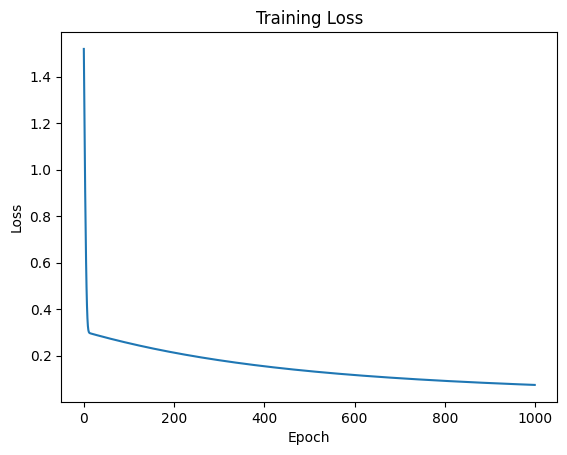

In [12]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()